In [12]:
import numpy as np
import pandas as pd
import random
from datetime import datetime, timedelta

## Generatig dataset

In [13]:
NUM_OF_USER = 100
DAYS = 10
EVENTS_PER_USER = (5,20)
start_date = datetime(2026,4,1)
event_types = ["app_open", "scroll", "click", "like", "purchase"]
platforms = ["mobile", "web"]
apps = ["instagram", "youtube", "whatsapp", "twitter", "amazon"]

data = []

for user in range(1,NUM_OF_USER+1):
    for day in range(DAYS):
        date = start_date + timedelta(day)

        num_events = random.randint(*EVENTS_PER_USER)

        for events in range(num_events):
            timestamp = date + timedelta(
                seconds=random.randint(0, 86400)
            )
            event_type = random.choice(event_types)
            platform = random.choice(platforms)
            app_name = random.choice(apps)
            duration = np.random.randint(5, 600)

            data.append([f'user_id {user}',timestamp,event_type,platform,app_name,duration])

df = pd.DataFrame(data, columns=["user_id", "timestamp", "event_type","platform", "app_name", "duration"])

print(len(df))

df.to_csv('user_behavior_data.csv',index=False)

            
                            

12419


## Inject mess in data

### missing values

In [15]:
for _ in range(200):
    idx = random.randint(0,len(df)-1)
    df.at[idx, "duration"] = None

## Duplicate values

In [16]:
df = pd.concat([df, df.sample(100)])

### Inconsistent app names

In [18]:
df.loc[df.sample(200).index, "app_name"] = "Insta"

### Outliers

In [19]:
for _ in range(50):
    idx = random.randint(0,len(df)-1)
    df.at[idx, "duration"] = 50000

## Data cleaning

### Standardize structure

In [20]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

### Missing values

In [21]:
df.isnull().sum()

user_id         2
timestamp       2
event_type      2
platform        2
app_name        2
duration      198
dtype: int64

In [22]:
df = df.dropna(subset=['user_id','timestamp','event_type'])

In [24]:
df.loc[:, "platform"] = df.groupby("user_id")["platform"] \
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "unknown"))

In [25]:
df.loc[:,"app_name"] = df.groupby("user_id")["app_name"] \
                   .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "unknown"))

In [26]:
df['duration'] = df["duration"].fillna(df["duration"].median())

In [27]:
df.isnull().sum()

user_id       0
timestamp     0
event_type    0
platform      0
app_name      0
duration      0
dtype: int64

### Remove duplicates

In [28]:
df = df.drop_duplicates(subset=['user_id','timestamp','event_type','app_name'])

### inconsistent app names

In [29]:
df['app_name'] = df['app_name'].str.lower()

app_map = {"insta":"instagram","ig": "instagram"}

df['app_name'] = df['app_name'].replace(app_map)

### Handle outliers

In [30]:
q1 = df['duration'].quantile(0.25)
q3 = df['duration'].quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
df['duration'] =  df["duration"].clip(upper=upper_bound)

## Sessionization

In [32]:
df = df.sort_values(by=['user_id','timestamp'])
df['time_diff'] = df.groupby('user_id')['timestamp'].diff()

session_gap = pd.Timedelta(minutes=30)
df['new_session'] = (df['time_diff'] > session_gap) | (df['time_diff'].isna())

In [33]:
df['session_id'] = df.groupby('user_id')['new_session'].cumsum()

In [35]:
session_df = df.groupby(['user_id','session_id']).agg(
    session_start = ('timestamp','min'),
    session_end = ('timestamp','max'),
    total_events = ('event_type','count'),
    total_duration = ('duration','sum'),
    unique_apps = ('app_name','nunique')
).reset_index()

In [38]:
session_df['session_lenght'] = (session_df['session_end'] - session_df['session_start']).dt.total_seconds()

In [41]:
session_df

,user_id,session_id,session_start,session_end,total_events,total_duration,unique_apps,session_lenght
0,user_id 1,1,2026-04-01 02:44:46,2026-04-01 03:04:52,2,643.0,2,1206.0
1,user_id 1,2,2026-04-01 03:49:16,2026-04-01 03:49:16,1,322.0,1,0.0
2,user_id 1,3,2026-04-01 11:08:51,2026-04-01 11:08:51,1,18.0,1,0.0
3,user_id 1,4,2026-04-01 12:41:44,2026-04-01 12:41:44,1,583.0,1,0.0
4,user_id 1,5,2026-04-01 13:18:34,2026-04-01 13:18:34,1,288.0,1,0.0
...,...,...,...,...,...,...,...,...
9479,user_id 99,99,2026-04-10 16:47:28,2026-04-10 16:48:52,2,482.0,1,84.0
9480,user_id 99,100,2026-04-10 17:48:35,2026-04-10 17:48:35,1,508.0,1,0.0
9481,user_id 99,101,2026-04-10 18:34:31,2026-04-10 18:34:31,1,455.0,1,0.0
9482,user_id 99,102,2026-04-10 19:22:04,2026-04-10 19:22:04,1,477.0,1,0.0


## Feature Engineering

In [46]:
user_df = session_df.groupby('user_id').agg(
    total_sessions = ('session_id','nunique'),
    avg_session_lenght = ('session_lenght','mean'),
    total_time_spent = ('total_duration','sum'),
    avg_event_per_session = ('total_events','mean'),
    avg_unique_apps = ('unique_apps', 'mean')
).reset_index()

In [47]:
df["hour"] = df["timestamp"].dt.hour
time_features = df.groupby("user_id").agg(
    peak_hour=("hour", lambda x: x.value_counts().idxmax()),
    night_usage_ratio=("hour", lambda x: ((x >= 22) | (x <= 5)).mean())
).reset_index()

In [49]:
user_df = user_df.merge(time_features, on="user_id", how="left")

In [52]:
user_df["sessions_per_day"] = user_df["total_sessions"] / 10  
user_df["short_session_ratio"] = session_df.groupby("user_id")["session_lenght"] \
    .apply(lambda x: (x < 300).mean()).values

In [53]:
app_usage = df.groupby(["user_id", "app_name"]).size().reset_index(name="count")

top_app = app_usage.sort_values(["user_id", "count"], ascending=[True, False]) \
                   .drop_duplicates("user_id")

top_app = top_app[["user_id", "app_name"]].rename(columns={"app_name": "favorite_app"})

user_df = user_df.merge(top_app, on="user_id", how="left")

## Clustering 

In [54]:
X = user_df.drop(columns=["user_id"])
X = pd.get_dummies(X, drop_first=True)

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

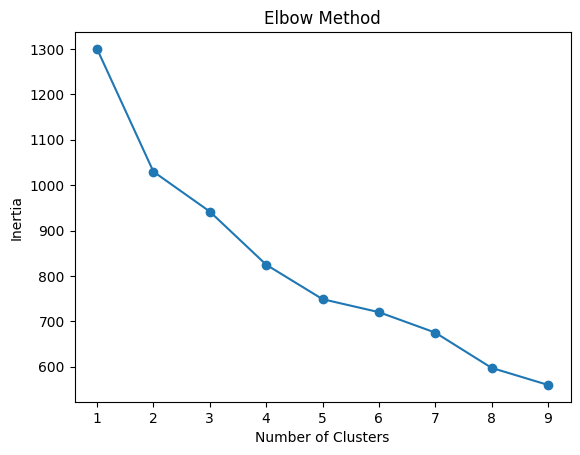

In [56]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [57]:
kmeans = KMeans(n_clusters=5, random_state=42)
user_df["cluster"] = kmeans.fit_predict(X_scaled)

In [60]:
cluster_summary = user_df.groupby("cluster").mean(numeric_only=True)
print(cluster_summary)

         total_sessions  avg_session_lenght  total_time_spent  \
cluster                                                         
0             96.400000          238.530218      37624.533333   
1             86.482759          213.036347      32155.827586   
2            104.400000          251.659842      42079.325000   
3             92.777778          327.024340      38150.870370   
4            104.111111          294.476396      42973.666667   

         avg_event_per_session  avg_unique_apps  peak_hour  night_usage_ratio  \
cluster                                                                         
0                     1.297702         1.221180   8.800000           0.345640   
1                     1.253910         1.188405  11.103448           0.339212   
2                     1.299859         1.222591  12.100000           0.325834   
3                     1.370575         1.274128   9.703704           0.336966   
4                     1.337266         1.264779   8.555556

In [61]:
def label_cluster(row):
    if row["cluster"] == 0:
        return "Habit Checkers"
    elif row["cluster"] == 1:
        return "Deep Users"
    elif row["cluster"] == 2:
        return "Night Users"
    else:
        return "Balanced Users"

user_df["segment"] = user_df.apply(label_cluster, axis=1)

## LLM-based insight generation

In [62]:
cluster_summary = user_df.groupby("cluster").mean(numeric_only=True)

cluster_data = cluster_summary.round(2).to_dict(orient="index")
print(cluster_data)

{0: {'total_sessions': 96.4, 'avg_session_lenght': 238.53, 'total_time_spent': 37624.53, 'avg_event_per_session': 1.3, 'avg_unique_apps': 1.22, 'peak_hour': 8.8, 'night_usage_ratio': 0.35, 'sessions_per_day': 9.64, 'short_session_ratio': 0.81}, 1: {'total_sessions': 86.48, 'avg_session_lenght': 213.04, 'total_time_spent': 32155.83, 'avg_event_per_session': 1.25, 'avg_unique_apps': 1.19, 'peak_hour': 11.1, 'night_usage_ratio': 0.34, 'sessions_per_day': 8.65, 'short_session_ratio': 0.84}, 2: {'total_sessions': 104.4, 'avg_session_lenght': 251.66, 'total_time_spent': 42079.32, 'avg_event_per_session': 1.3, 'avg_unique_apps': 1.22, 'peak_hour': 12.1, 'night_usage_ratio': 0.33, 'sessions_per_day': 10.44, 'short_session_ratio': 0.82}, 3: {'total_sessions': 92.78, 'avg_session_lenght': 327.02, 'total_time_spent': 38150.87, 'avg_event_per_session': 1.37, 'avg_unique_apps': 1.27, 'peak_hour': 9.7, 'night_usage_ratio': 0.34, 'sessions_per_day': 9.28, 'short_session_ratio': 0.77}, 4: {'total_sess

In [75]:
from groq import Groq
import os

client = Groq(api_key=os.getenv("GROQ_API_KEY"))

prompt = f"""
You are a product-focused data analyst working on consumer behavior analytics.

Analyze the clusters below.

For each cluster:
- Give a short descriptive segment name
- Explain behavior in plain English (not technical)
- Suggest a targeted marketing or product strategy

Be specific and actionable. Avoid generic statements.

Cluster Data:
{cluster_data}
"""

response = client.chat.completions.create(
    model="llama-3.1-8b-instant",  
    messages=[{"role": "user", "content": prompt}],
    temperature=0.3
)

print(response.choices[0].message.content)

Based on the provided cluster data, I will analyze each cluster and provide a short descriptive segment name, explain behavior in plain English, and suggest a targeted marketing or product strategy.

**Cluster 1:**
- **Segment Name:** Casual Users
- **Behavior:** These users have a moderate number of sessions per day and spend a reasonable amount of time on the platform. They tend to use the platform during the day, with a peak hour around 11 am. They also tend to use a single app at a time and have a relatively short session length.
- **Targeted Marketing/ Product Strategy:** Offer a "Daily Essentials" package that includes a curated selection of popular apps and a personalized dashboard to help users stay organized. This package can be marketed as a convenient and efficient way to manage daily tasks.

**Cluster 2:**
- **Segment Name:** Power Users
- **Behavior:** These users have a high number of sessions per day and spend a significant amount of time on the platform. They tend to us